In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env.py
%run run.py connect

2025-07-18 15:59:19,358::INFO::settings.py::Setting loglevel to INFO
2025-07-18 15:59:19,359::INFO::settings.py::Setting stores to {}
2025-07-18 15:59:19,360::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-07-18 15:59:19,361::INFO::settings.py::Setting database.misc.create_tables to True
2025-07-18 15:59:19,362::INFO::settings.py::Setting enable_python_native_blobs to True
2025-07-18 15:59:19,362::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2025-07-18 15:59:19,363::INFO::settings.py::Setting database.user to celia
2025-07-18 15:59:19,366::INFO::settings.py::Setting database.password to celia
2025-07-18 15:59:19,427::INFO::connection.py::Connected celia@128.178.51.167:3309
2025-07-18 15:59:19,441::INFO::table.py::could not log event in table ~log


Connecting celia@128.178.51.167:3309


2025-07-18 15:59:19,918::INFO::table.py::could not log event in table ~log
2025-07-18 15:59:19,918::INFO::table.py::could not log event in table ~log
2025-07-18 15:59:19,937::INFO::table.py::could not log event in table ~log
2025-07-18 15:59:19,937::INFO::table.py::could not log event in table ~log
2025-07-18 15:59:19,967::INFO::table.py::could not log event in table ~log
2025-07-18 15:59:19,967::INFO::table.py::could not log event in table ~log
2025-07-18 15:59:19,994::INFO::table.py::could not log event in table ~log
2025-07-18 15:59:19,994::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema.base_analysis import DataFrame
from vr4mice.schema.vr4mice import Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema.interpolated_trajectories import (
    InterpolatedTrials,
    MeanXYTrajectory,
    MeanVelocities,
    YBinnedXYTrajectory,
)
from vr4mice.schema.session_metrics import TrialMetrics, SessionMetrics
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats
import warnings

warnings.filterwarnings("ignore")


style()

2025-07-18 15:59:20,129::INFO::table.py::could not log event in table ~log
2025-07-18 15:59:20,129::INFO::table.py::could not log event in table ~log


2025-07-18 15:59:20,140::INFO::table.py::could not log event in table ~log
2025-07-18 15:59:20,140::INFO::table.py::could not log event in table ~log


In [14]:
from vr4mice.schema.vr4mice import State, Video

In [6]:
from vr4mice.analysis.latency_testing import (
   detect_signal_polarity,
   filter_pulsed_signal,
   get_signals)

import cv2
import numpy as np

# From DJ directly

In [7]:
from vr4mice.schema.vr4mice import SignalsPhotodiode

SignalsPhotodiode()

dataset,start_time,photodiode_time timestamp of the photodiode signal,photodiode_read value of the photodiode signal,generated_frame_time timestamp of frame relative to the generated signal,generated_send_time time that the signal gets sent from the dlc processor,generated_signal the signal that is generated by the dlc processor
Jacana_2024-07-26_1,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
Jacana_2024-07-27_1,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
Jacana_2024-07-28_1,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
Jacana_2024-07-29_2,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
Latencytest1_2024-10-31_1,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
Latencytest1_2024-10-31_2,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
Latencytest1_2024-10-31_3,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
Latencytest1_2024-10-31_4,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
Latencytest1_2024-10-31_5,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
Latencytest1_2024-10-31_6,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=


In [8]:
from vr4mice.schema.vr4mice import SignalsPhotodiode

df = pd.DataFrame(
    {
        "photodiode_read": (
            SignalsPhotodiode() & {"dataset": "Latencytest2_2025-05-19_2"}
        ).fetch1("photodiode_read")
    }
)

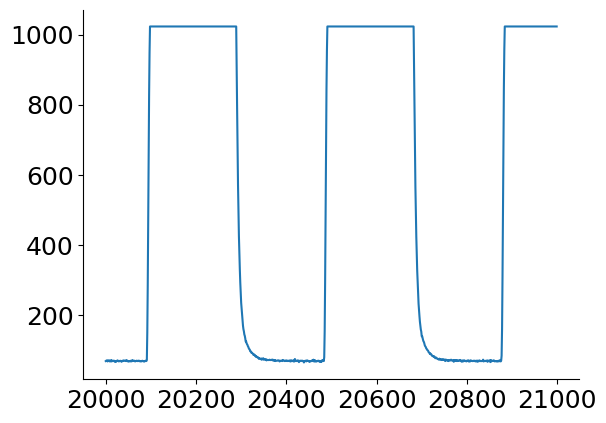

In [9]:
plt.plot(df["photodiode_read"][20000:21000])

In [10]:
from vr4mice.analysis.latency_testing import get_signals, find_rising_edges, get_latency

In [15]:
Video()

dataset,camera,doe YYYY-MM-DD,duration,fps,width,height,video_filepath,timestamp_filepath
Jacana_2024-07-26_1,Imagingsource,2024-07-26,1374,100,530,510,D:\AR_data\raw_data\Videos_dlc/Imagingsource_Jacana_2024-07-26_1_VIDEO.avi,/data/dlc_video/Imagingsource_Jacana_2024-07-26_1_TS.npy
Jacana_2024-07-27_1,Imagingsource,2024-07-27,4389,100,530,510,D:\AR_data\raw_data\Videos_dlc/Imagingsource_Jacana_2024-07-27_1_VIDEO.avi,/data/dlc_video/Imagingsource_Jacana_2024-07-27_1_TS.npy
Jacana_2024-07-28_1,Imagingsource,2024-07-28,None,None,None,None,Imagingsource_Jacana_2024-07-28_1_VIDEO.avi/Imagingsource_Jacana_2024-07-28_1_VIDEO.avi,/data/dlc_video/Imagingsource_Jacana_2024-07-28_1_TS.npy
Jacana_2024-07-29_2,Imagingsource,2024-07-29,None,None,None,None,Imagingsource_Jacana_2024-07-29_2_VIDEO.avi/Imagingsource_Jacana_2024-07-29_2_VIDEO.avi,/data/dlc_video/Imagingsource_Jacana_2024-07-29_2_TS.npy
Jacana_2024-07-30_1,Imagingsource,2024-07-30,None,None,None,None,Imagingsource_Jacana_2024-07-30_1_VIDEO.avi/Imagingsource_Jacana_2024-07-30_1_VIDEO.avi,/data/dlc_video/Imagingsource_Jacana_2024-07-30_1_TS.npy
Jacana_2024-07-31_1,Imagingsource,2024-07-31,None,None,None,None,Imagingsource_Jacana_2024-07-31_1_VIDEO.avi/Imagingsource_Jacana_2024-07-31_1_VIDEO.avi,/data/dlc_video/Imagingsource_Jacana_2024-07-31_1_TS.npy
Jacana_2024-08-01_1,Imagingsource,2024-08-01,None,None,None,None,Imagingsource_Jacana_2024-08-01_1_VIDEO.avi/Imagingsource_Jacana_2024-08-01_1_VIDEO.avi,/data/dlc_video/Imagingsource_Jacana_2024-08-01_1_TS.npy
Jacana_2024-08-02_1,Imagingsource,2024-08-02,None,None,None,None,Imagingsource_Jacana_2024-08-02_1_VIDEO.avi/Imagingsource_Jacana_2024-08-02_1_VIDEO.avi,/data/dlc_video/Imagingsource_Jacana_2024-08-02_1_TS.npy
Jacana_2024-08-05_2,Imagingsource,2024-08-05,None,None,None,None,Imagingsource_Jacana_2024-08-05_2_VIDEO.avi/Imagingsource_Jacana_2024-08-05_2_VIDEO.avi,/data/dlc_video/Imagingsource_Jacana_2024-08-05_2_TS.npy
Jacana_2024-08-06_1,Imagingsource,2024-08-06,None,None,None,None,Imagingsource_Jacana_2024-08-06_1_VIDEO.avi/Imagingsource_Jacana_2024-08-06_1_VIDEO.avi,/data/dlc_video/Imagingsource_Jacana_2024-08-06_1_TS.npy


In [ ]:
seconds = 2828.939302
print(f"Total duration: {seconds} seconds")

Total duration: 2828.939302 seconds


In [ ]:
import cv2


def count_frames_opencv(video_path):
    cap = cv2.VideoCapture(video_path)

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return frame_count


# Usage
video_path = "/app/vr4mice/videos/Nightingale_2024-08-14_1_visual_roi.mkv"
frames = count_frames_opencv(video_path)
print(f"Total frames: {frames}")

Total frames: 339565


In [ ]:
seconds = frames / 120
print(f"Total duration: {seconds} seconds")

Total duration: 2829.7083333333335 seconds
